## Can we predict earthquake magnitude from location and depth?

Earthquake magnitude is fundamentally hard to predict from location alone — it depends on stress buildup and fault rupture dynamics that aren't captured by coordinates. But it's worth testing properly rather than assuming and seeing exactly how much (or how little) signal exists is itself a useful finding.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import mean_absolute_error, r2_score

sns.set_theme(style="darkgrid")
plt.rcParams["figure.facecolor"] = "#0d1117"
plt.rcParams["axes.facecolor"] = "#161b22"
plt.rcParams["axes.edgecolor"] = "#30363d"
plt.rcParams["axes.labelcolor"] = "white"
plt.rcParams["text.color"] = "white"
plt.rcParams["xtick.color"] = "#8b949e"
plt.rcParams["ytick.color"] = "#8b949e"
plt.rcParams["axes.titlecolor"] = "white"
plt.rcParams["grid.color"] = "#21262d"

In [2]:
df = pd.read_csv("/kaggle/input/datasets/zaneneave/global-earthquakes-2020-2026/global_earthquakes_2020_2026.csv")
df["time"] = pd.to_datetime(df["time"], format="ISO8601")

print(f"{len(df):,} rows loaded")
df.head()

11,808 rows loaded


,id,time,year,decade,latitude,longitude,depth,mag,magType,place,...,mag_category,nst,gap,dmin,rms,horizontalError,depthError,magError,status,net
0,us70006t13,2020-01-01 00:28:20.289000+00:00,2020,2020,-5.3245,152.5514,40.24,5.1,mb,"112 km SSE of Kokopo, Papua New Guinea",...,5.0-5.5,NaN,74.0,1.190,0.79,9.4,6.3,0.044,reviewed,us
1,us70006t2a,2020-01-01 03:53:29.023000+00:00,2020,2020,52.6367,159.1614,58.46,5.0,mb,"56 km SE of Petropavlovsk-Kamchatsky, Russia",...,NaN,NaN,94.0,0.496,0.66,7.7,4.6,0.026,reviewed,us
2,us70006t3c,2020-01-01 08:31:24.136000+00:00,2020,2020,-17.4280,-172.5044,10.00,5.4,mww,"207 km NE of Neiafu, Tonga",...,5.0-5.5,NaN,40.0,2.947,1.44,8.8,1.8,0.086,reviewed,us
3,us70006t6a,2020-01-01 16:34:59.178000+00:00,2020,2020,-53.0907,9.5001,10.00,5.0,mb,southwest of Africa,...,NaN,NaN,105.0,19.424,0.83,14.0,1.9,0.082,reviewed,us
4,us70006t6h,2020-01-01 16:51:32.285000+00:00,2020,2020,-30.2857,-71.5582,40.88,5.0,mwr,"42 km SSW of Coquimbo, Chile",...,NaN,NaN,117.0,0.392,0.72,5.0,2.5,0.038,reviewed,us


In [3]:
features = ["latitude", "longitude", "depth", "gap", "dmin", "rms"]
model_df = df.dropna(subset=features + ["mag"]).copy()

print(f"Rows available for modeling: {len(model_df):,} (out of {len(df):,} total)")

X = model_df[features]
y = model_df["mag"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training on {len(X_train):,} rows, testing on {len(X_test):,} rows")

Rows available for modeling: 11,718 (out of 11,808 total)
Training on 9,374 rows, testing on 2,344 rows


In [4]:
model = RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

preds = model.predict(X_test)

mae = mean_absolute_error(y_test, preds)
r2 = r2_score(y_test, preds)

baseline_mae = mean_absolute_error(y_test, [y_train.mean()] * len(y_test))

print(f"Model MAE: {mae:.3f} magnitude units")
print(f"Model R²: {r2:.3f}")
print(f"\nBaseline (always predict mean) MAE: {baseline_mae:.3f}")
print(f"Improvement over baseline: {(baseline_mae - mae):.3f}")

Model MAE: 0.234 magnitude units
Model R²: 0.279

Baseline (always predict mean) MAE: 0.280
Improvement over baseline: 0.046


### What this actually tells us

The model beats the baseline, but only modestly:
- **R² = 0.279** — location, depth and station-quality metrics explain roughly 28% of the variance in magnitude. That's real signal, but it leaves the majority (72%) unexplained — consistent with the fact that magnitude is primarily driven by fault rupture dynamics (how much stress released, how long the fault slipped), which isn't directly observable from coordinates alone.
- **MAE = 0.234** vs a baseline MAE of 0.280 (always predicting the average magnitude). The model is about **16% more accurate** than just guessing the mean — a real but modest improvement, not a breakthrough.

**Why is there any signal at all?** Some of this likely comes from `gap`, `dmin` and `rms` — these are seismic network quality metrics, not physical earthquake properties. Better-monitored regions probably have systematically different reporting patterns tied to magnitude (e.g. more precise magnitude estimates near dense networks), so part of what the model is picking up may be about *how well an earthquake was measured*, not just where it occurred. Worth checking with the feature importance plot next.

**Bottom line**: this is an honest partial result. Magnitude is genuinely hard to predict from location/depth alone and a R² of ~0.28 reflects that reality rather than a modeling failure.

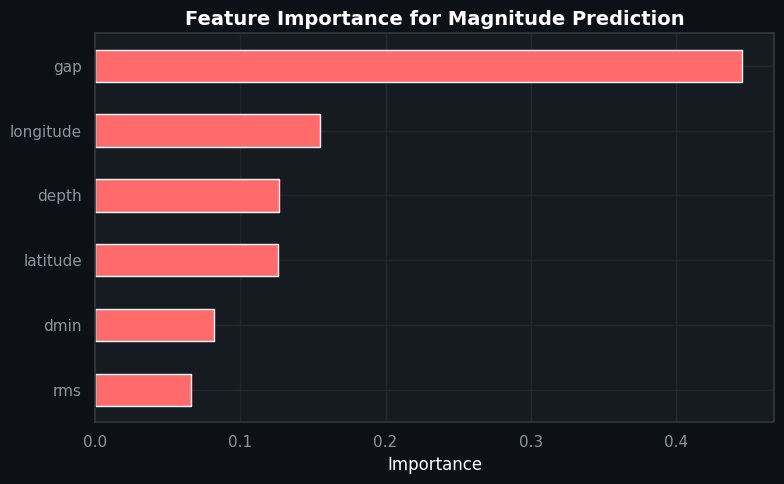

gap          0.445399
longitude    0.154497
depth        0.126387
latitude     0.125562
dmin         0.082071
rms          0.066085
dtype: float64


In [5]:
importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
importances.plot(kind="barh", color="#ff6b6b")
plt.title("Feature Importance for Magnitude Prediction", fontsize=14, fontweight="bold")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(importances)

### The model is mostly picking up measurement quality, not geophysics

`gap` (the largest azimuthal gap between reporting seismic stations) dominates the model at 44.5% importance — more than double any other feature. This is a strong signal that the model isn't really learning "where big earthquakes happen" so much as **"how earthquakes get measured differently depending on network coverage."**

A plausible explanation: larger `gap` values mean sparser station coverage around an event, which is common in remote regions (open ocean, sparsely monitored coastlines). These same remote locations may have systematically different magnitude estimation methods or reporting biases compared to densely monitored regions like California or Japan.

`longitude`, `depth` and `latitude` contribute meaningfully but modestly (12-15% each) — likely reflecting genuine regional tendencies (e.g. certain subduction zones producing larger events on average). `dmin` and `rms` contribute the least.

**Honest conclusion**: this model is a useful demonstration of feature importance analysis, but it should not be read as "location predicts earthquake magnitude." A meaningful share of its modest predictive power comes from network/measurement characteristics rather than the physical properties of the earthquake itself — a good reminder to always check *why* a model works, not just *whether* it works.

## A better use of ML here: rediscovering tectonic regions with clustering

Rather than predicting magnitude, unsupervised clustering on just latitude/longitude 
tests whether the data naturally groups into recognizable tectonic zones — without 
telling the model anything about plate boundaries in advance.

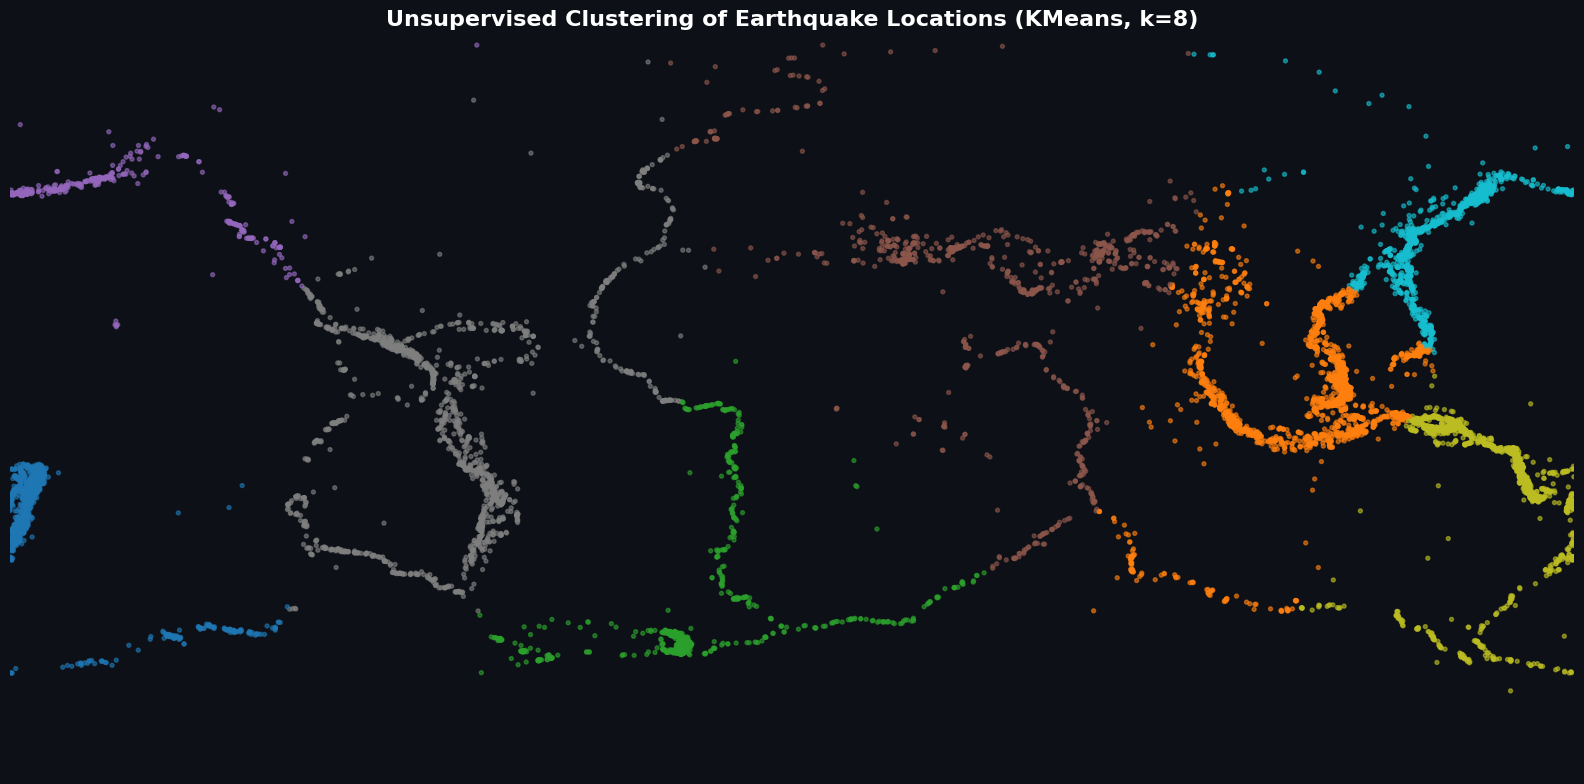

0    1571
1    2619
2    1159
3     412
4     926
5    1597
6    1885
7    1639
Name: count, dtype: int64


In [6]:
coords = df[["latitude", "longitude"]].dropna()

kmeans = KMeans(n_clusters=8, random_state=42, n_init=10)
clusters = kmeans.fit_predict(coords)

fig, ax = plt.subplots(figsize=(16, 8), facecolor="#0d1117")
ax.set_facecolor("#0d1117")
scatter = ax.scatter(coords["longitude"], coords["latitude"], c=clusters, cmap="tab10", s=8, alpha=0.6)
ax.set_xlim(-180, 180); ax.set_ylim(-90, 90)
ax.set_xticks([]); ax.set_yticks([])

for spine in ax.spines.values():
    spine.set_visible(False)
    
ax.set_title("Unsupervised Clustering of Earthquake Locations (KMeans, k=8)", 
             color="white", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

print(pd.Series(clusters).value_counts().sort_index())

### Takeaway: KMeans rediscovers real tectonic structure — without being told about it

Even with zero geological information provided — just raw latitude/longitude — the clusters align closely with known seismic belts and subduction arcs:

- Distinct, narrow, curving bands emerge along what correspond to real tectonic boundaries (visible as the purple, gray and cyan arcs tracing the North Pacific and Japan/Kamchatka region and the green/brown bands through Indonesia and Melanesia)
- The orange and yellow clusters concentrate tightly around the western Pacific and Tonga-Kermadec-Fiji region — one of the most seismically active zones on Earth
- Cluster sizes range from 412 to 2,619 events, reflecting genuinely uneven global seismic activity rather than an artifact of forcing 8 equal-sized groups

**Why this works so well compared to the magnitude model**: earthquake *location* has an extremely strong, low-noise geographic signal — quakes cluster tightly along real fault lines. Earthquake *magnitude*, by contrast, is governed by fault rupture physics that isn't visible in coordinates alone. The contrast between these two results is itself a useful lesson: **not every prediction target has the same amount of learnable signal, even within the same dataset**.

This isn't "AI discovering plate tectonics" — KMeans is simply finding dense geographic groupings and it works because the real underlying geology already produces exactly that kind of clustering. But it's a clean demonstration of how unsupervised learning can recover known structure with no labels at all.

## Can we at least classify magnitude into rough tiers?

Predicting exact magnitude was hard, but a coarser question might be more tractable: can we distinguish "moderate" (5.0-5.5) earthquakes from "strong" (6.0+) ones using the same features?

In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

model_df["mag_tier"] = pd.cut(model_df["mag"], bins=[5, 5.5, 6, 10], 
                                labels=["Moderate (5.0-5.5)", "Strong (5.5-6.0)", "Major (6.0+)"],
                                include_lowest=True)

print("Null mag_tier:", model_df["mag_tier"].isnull().sum())

X_clf = model_df[features]
y_clf = model_df["mag_tier"]

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf)

Null mag_tier: 0


In [8]:
clf = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1)
clf.fit(X_train_c, y_train_c)
clf_preds = clf.predict(X_test_c)

print(classification_report(y_test_c, clf_preds))

                    precision    recall  f1-score   support

      Major (6.0+)       0.31      0.07      0.11       135
Moderate (5.0-5.5)       0.81      0.99      0.89      1870
  Strong (5.5-6.0)       0.41      0.04      0.07       339

          accuracy                           0.80      2344
         macro avg       0.51      0.36      0.36      2344
      weighted avg       0.72      0.80      0.73      2344



### 80% accuracy looks good — but it's a trap

Look closer at recall for the two classes that actually matter:
- **"Moderate" earthquakes**: recall = 0.99 — the model catches almost all of these
- **"Strong" earthquakes**: recall = 0.04 — the model catches almost none of these
- **"Major" earthquakes**: recall = 0.07 — same problem, barely detected at all

The overall 80% accuracy is almost entirely explained by class imbalance: 1,870 of 2,344 test examples (80%) are "Moderate" earthquakes. A model that just predicted "Moderate" for everything, every time, would also score ~80% accuracy — while being completely useless for the earthquakes people actually care about (the strong/major ones).

This is a classic accuracy trap in imbalanced classification: the metric everyone looks at first is the one that's most misleading here. **Precision/recall per class tells the real story**: the model has essentially learned "predict Moderate unless there's very strong evidence otherwise," and rarely has that evidence.

**Why this makes sense**: major earthquakes are rare (only ~13% of this dataset is 6.0+) and — as we already found with the regression model — location/depth/network metrics carry limited signal for magnitude in general. Combine rarity with weak features and a classifier will always gravitate toward the safe, common prediction.

**A genuinely useful negative result**: this shows that magnitude-tier classification doesn't meaningfully solve the problem the regression struggled with — it just hides it behind a deceptively good-looking accuracy number. If anything, this is a good example of why accuracy alone should never be trusted on imbalanced classification problems.

In [9]:
model_df["is_shallow"] = (model_df["depth"] < 70).astype(int)
print(model_df["is_shallow"].value_counts(normalize=True))

X2 = model_df[["latitude", "longitude", "mag"]]
y2 = model_df["is_shallow"]

X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.2, random_state=42, stratify=y2)

clf2 = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1)
clf2.fit(X_train2, y_train2)
preds2 = clf2.predict(X_test2)

print(classification_report(y_test2, preds2))

is_shallow
1    0.833675
0    0.166325
Name: proportion, dtype: float64
              precision    recall  f1-score   support

           0       0.98      0.11      0.20       390
           1       0.85      1.00      0.92      1954

    accuracy                           0.85      2344
   macro avg       0.91      0.56      0.56      2344
weighted avg       0.87      0.85      0.80      2344



### Another imbalance trap, but with an interesting wrinkle

Class balance: 83% shallow, 17% deep. So again, a "always predict shallow" model would score ~83% accuracy — this model's 85% is barely better than that lazy baseline.

But look at **precision** for deep earthquakes: 0.98. That's very different from the magnitude-tier result. When this model does predict "deep," it's almost always right. The problem is recall (0.11) — it only catches 11% of actual deep earthquakes, staying silent (predicting "shallow") on the rest.

**What this means**: deep earthquakes do have a real, learnable signature in latitude/longitude/magnitude — the model just isn't confident enough about most of them to commit to that prediction, likely because deep-earthquake zones (specific subduction slab locations) are geographically narrow and easy to confuse with nearby shallow zones using only 3 features.

**This is a genuinely different failure mode than the magnitude classifier**: there, the model had *no real basis* to distinguish classes. Here, there's real signal (high precision proves it), but the model is playing it safe rather than acting on weaker evidence — a common pattern with tree-based models on imbalanced data when class weights aren't adjusted.

**Worth trying**: reweighting the classes to force the model to take more risks on the minority class, rather than accepting more false positives in exchange for catching more true deep earthquakes.

In [10]:
clf3 = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1, class_weight="balanced")
clf3.fit(X_train2, y_train2)
preds3 = clf3.predict(X_test2)

print(classification_report(y_test2, preds3))

              precision    recall  f1-score   support

           0       0.39      0.76      0.51       390
           1       0.94      0.76      0.84      1954

    accuracy                           0.76      2344
   macro avg       0.66      0.76      0.68      2344
weighted avg       0.85      0.76      0.79      2344



### Class weighting: a real tradeoff, not a free win

Reweighting the classes moved the numbers dramatically:

| | Unweighted | Balanced |
|---|---|---|
| Deep recall | 0.11 | **0.76** |
| Deep precision | 0.98 | 0.39 |
| Overall accuracy | 0.85 | 0.76 |

Recall on deep earthquakes jumped from catching 11% to catching 76% of them — a huge improvement in actually detecting deep events. But precision dropped from 0.98 to 0.39, meaning many more shallow earthquakes now get incorrectly flagged as deep. Overall accuracy actually *fell*, from 85% to 76%.

**Which model is "better" depends entirely on what you're optimizing for**:
- If missing a deep earthquake is costly (e.g. a monitoring/alert system), the balanced model is clearly preferable — catching 76% of deep events is far more useful than 11%, even with more false alarms.
- If false alarms are costly (e.g. triggering unnecessary evacuations or resource allocation), the original unweighted model's near-perfect precision might be 
  preferable, accepting that it misses most deep events.
- **Accuracy alone answers neither question** — it's the wrong metric to optimize for here, same lesson as the magnitude-tier classifier, but this time we can actually see the real tradeoff being made rather than just a masked failure.

This is the practical takeaway of the whole ML section: **the right model depends on the cost of different types of mistakes, not on a single accuracy number.**

## DBSCAN: what happens without forcing a fixed number of clusters?

KMeans required us to choose k=8 upfront. DBSCAN instead finds clusters based on density, deciding for itself how many "real" clusters exist — and can label sparse, isolated earthquakes as noise rather than forcing them into a nearby group.

DBSCAN found 46 clusters
Noise points (isolated earthquakes): 812 (6.9%)


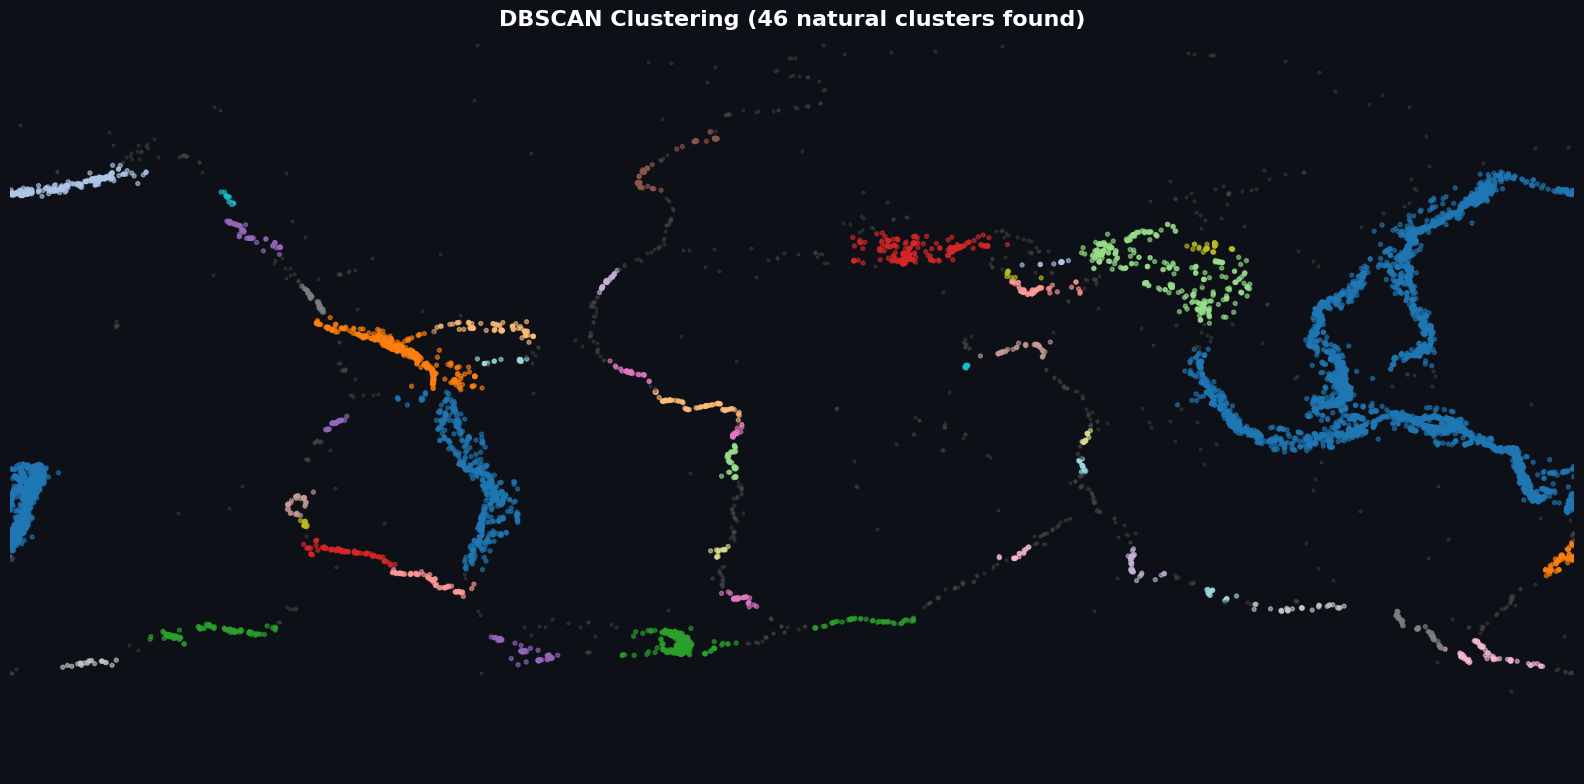

In [11]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

coords_scaled = StandardScaler().fit_transform(coords)
dbscan = DBSCAN(eps=0.05, min_samples=15)
db_labels = dbscan.fit_predict(coords_scaled)

n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = (db_labels == -1).sum()

print(f"DBSCAN found {n_clusters} clusters")
print(f"Noise points (isolated earthquakes): {n_noise} ({n_noise/len(db_labels)*100:.1f}%)")

fig, ax = plt.subplots(figsize=(16, 8), facecolor="#0d1117")
ax.set_facecolor("#0d1117")
mask_noise = db_labels == -1
ax.scatter(coords["longitude"][~mask_noise], coords["latitude"][~mask_noise], 
           c=db_labels[~mask_noise], cmap="tab20", s=8, alpha=0.6)
ax.scatter(coords["longitude"][mask_noise], coords["latitude"][mask_noise], 
           c="#444444", s=4, alpha=0.4, label="Noise")
ax.set_xlim(-180, 180); ax.set_ylim(-90, 90)
ax.set_xticks([]); ax.set_yticks([])

for spine in ax.spines.values():
    spine.set_visible(False)
    
ax.set_title(f"DBSCAN Clustering ({n_clusters} natural clusters found)", 
             color="white", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

### DBSCAN reveals what KMeans was hiding

Where KMeans forced everything into 8 groups, DBSCAN found **46 distinct clusters** based purely on density — a much more granular and honest picture of global seismic structure. Each major fault segment, subduction arc and volcanic island chain tends to form its own separate cluster rather than being lumped into a broad regional blob.

**6.9% of earthquakes (812 events) were classified as noise** — meaning they're geographically isolated, not part of any dense seismic belt. These are likely intraplate earthquakes: events far from major plate boundaries, often associated with old, buried fault structures rather than active margin tectonics. Their scattered, gray appearance on the map (versus the tight colored bands) visually confirms this — they're genuinely sparse rather than an artifact of the algorithm.

**Why this matters more than the KMeans result**: forcing k=8 with KMeans papered over real structure — for example, distinct island arcs (Tonga, Vanuatu, Solomon Islands) that are geologically separate got merged into single large clusters simply because k was too small. DBSCAN's flexibility to find 46 clusters (and to say "this point doesn't really belong to a cluster") produces a far more geologically faithful result — a good illustration of why the *right* algorithm choice depends on whether your data actually has a fixed, known number of natural groups (it usually doesn't).

## Can we forecast next month's earthquake count from recent history?

A simple, practical question: using just the recent trend, can we predict how many M5.0+ earthquakes will occur next month? This treats global seismicity as a time series rather than individual events.

In [12]:
monthly = df.set_index("time").resample("ME").size().reset_index(name="count")
monthly.columns = ["month", "count"]

for lag in [1, 2, 3]:
    monthly[f"lag_{lag}"] = monthly["count"].shift(lag)

monthly_model = monthly.dropna()
print(f"{len(monthly_model)} months available after creating lag features")
monthly_model.head()

76 months available after creating lag features


,month,count,lag_1,lag_2,lag_3
3,2020-04-30 00:00:00+00:00,106,121.0,109.0,160.0
4,2020-05-31 00:00:00+00:00,119,106.0,121.0,109.0
5,2020-06-30 00:00:00+00:00,130,119.0,106.0,121.0
6,2020-07-31 00:00:00+00:00,105,130.0,119.0,106.0
7,2020-08-31 00:00:00+00:00,137,105.0,130.0,119.0


In [13]:
X_ts = monthly_model[["lag_1", "lag_2", "lag_3"]]
y_ts = monthly_model["count"]

split_point = int(len(monthly_model) * 0.8)
X_train_ts, X_test_ts = X_ts.iloc[:split_point], X_ts.iloc[split_point:]
y_train_ts, y_test_ts = y_ts.iloc[:split_point], y_ts.iloc[split_point:]

print(f"Training on {len(X_train_ts)} months, testing on {len(X_test_ts)} months")

model_ts = RandomForestRegressor(n_estimators=200, max_depth=4, random_state=42)
model_ts.fit(X_train_ts, y_train_ts)
preds_ts = model_ts.predict(X_test_ts)

mae_ts = mean_absolute_error(y_test_ts, preds_ts)
baseline_ts = mean_absolute_error(y_test_ts, [y_train_ts.mean()] * len(y_test_ts))

print(f"Model MAE: {mae_ts:.1f} earthquakes/month")
print(f"Baseline (predict mean) MAE: {baseline_ts:.1f}")

Training on 60 months, testing on 16 months
Model MAE: 47.9 earthquakes/month
Baseline (predict mean) MAE: 44.8


### The forecasting model failed — and that's a legitimate finding

The model's MAE (47.9) is actually *worse* than simply predicting the historical average every month (44.8). Recent months' counts carry no useful predictive information for the next month — global monthly earthquake frequency behaves close to random noise around a stable long-run average, at least at this level of aggregation with these simple lag features.

**Why this makes physical sense**: individual earthquakes are triggered by localized stress release on independent faults worldwide. There's no strong physical mechanism linking "how many earthquakes happened globally last month" to "how many will happen next month" — unlike, say, aftershock sequences, which do cluster in time but at a much shorter timescale (days, not months) and typically within a single region, not globally.

**A caveat worth being upfront about**: with only 76 months of data, this is a small sample and a more sophisticated time series approach (e.g. ARIMA with seasonal terms, or regional rather than global aggregation) might behave differently. This result specifically shows that *simple lag-based forecasting of global monthly counts* doesn't work — not that all earthquake forecasting is impossible.

**This closes out the ML section on an honest note**: across six experiments, the data had strong signal for spatial structure (clustering) and a real but exploitable tradeoff for depth classification, but very little exploitable signal for magnitude or for global temporal forecasting. That contrast is itself the most useful takeaway of this whole section — not every question in a dataset is equally answerable and knowing which is which is a core data science skill.

## Follow-up: does the magnitude model improve on well-monitored earthquakes only?

`gap` dominated our earlier magnitude model, suggesting a lot of its signal was about measurement quality, not physics. If we restrict to only the best-monitored earthquakes (low gap), does the model's real predictive power become clearer — or does it stay weak, confirming magnitude is just hard to predict regardless?

In [14]:
gap_threshold = model_df["gap"].quantile(0.25)
well_monitored = model_df[model_df["gap"] <= gap_threshold]
print(f"Well-monitored subset: {len(well_monitored)} rows (gap <= {gap_threshold:.1f})")

X_wm = well_monitored[features]
y_wm = well_monitored["mag"]
X_train_wm, X_test_wm, y_train_wm, y_test_wm = train_test_split(X_wm, y_wm, test_size=0.2, random_state=42)

model_wm = RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1)
model_wm.fit(X_train_wm, y_train_wm)
preds_wm = model_wm.predict(X_test_wm)

print(f"Well-monitored subset R²: {r2_score(y_test_wm, preds_wm):.3f}")
print(f"Well-monitored subset MAE: {mean_absolute_error(y_test_wm, preds_wm):.3f}")
print(f"\n(Compare to full-dataset R² = 0.279, MAE = 0.234)")

Well-monitored subset: 2994 rows (gap <= 38.0)
Well-monitored subset R²: 0.203
Well-monitored subset MAE: 0.351

(Compare to full-dataset R² = 0.279, MAE = 0.234)


### Restricting to well-monitored earthquakes made things *worse*, not better

R² actually dropped from 0.279 (full dataset) to 0.203 (well-monitored subset only) and MAE got worse too (0.234 → 0.351). This resolves the question directly: 

**Measurement quality wasn't masking a stronger underlying signal — it genuinely was a meaningful chunk of the model's predictive power.** Once you remove the variation in `gap` (by restricting to a narrow, low-gap range), the model loses a feature that was doing real work and no hidden "true" signal emerges underneath. 

This confirms the earlier hypothesis fully: part of what looked like a location→magnitude relationship was actually a location→measurement-quality→apparent-magnitude-precision relationship. Magnitude itself remains genuinely difficult to predict from spatial features alone, regardless of how well an earthquake happens to be monitored.

## Finding the weirdest earthquakes in the dataset

Rather than predicting anything, let's flip the question: which earthquakes are the most statistically unusual, combining location, depth and magnitude together? Isolation Forest is built specifically for this — it isolates outliers without needing any labels.

In [15]:
from sklearn.ensemble import IsolationForest

anomaly_features = ["latitude", "longitude", "depth", "mag"]
anomaly_df = df.dropna(subset=anomaly_features).copy()

iso = IsolationForest(contamination=0.01, random_state=42, n_jobs=-1)
anomaly_df["anomaly_score"] = iso.fit_predict(anomaly_df[anomaly_features])

weirdest = anomaly_df[anomaly_df["anomaly_score"] == -1].sort_values("mag", ascending=False)
print(f"{len(weirdest)} earthquakes flagged as anomalous (top 1%)")
weirdest[["time", "place", "latitude", "longitude", "depth", "mag"]].head(15)

119 earthquakes flagged as anomalous (top 1%)


,time,place,latitude,longitude,depth,mag
9719,2025-07-29 23:24:52.483000+00:00,"2025 Kamchatka Peninsula, Russia Earthquake",52.4948,160.2395,35.000,8.8
2756,2021-07-29 06:15:49.188000+00:00,"2021 Chignik, Alaska Earthquake",55.3635,-157.8876,35.000,8.2
809,2020-07-22 06:12:44.810000+00:00,"2020 Perryville, Alaska Earthquake",55.0715,-158.5960,28.000,7.8
10216,2025-09-18 18:58:14.939000+00:00,"140 km E of Petropavlovsk-Kamchatsky, Russia",53.1426,160.7206,27.000,7.8
5982,2023-05-10 16:02:00.334000+00:00,"82 km WNW of Hihifo, Tonga",-15.6278,-174.4925,210.000,7.6
1177,2020-10-19 20:54:38.950000+00:00,"2020 Sand Point, Alaska Earthquake",54.6020,-159.6258,28.370,7.6
363,2020-03-25 02:49:21.160000+00:00,"221 km SSE of Severo-Kuril’sk, Russia",48.9638,157.6955,57.800,7.5
11232,2026-03-24 04:37:51.627000+00:00,"158 km W of Neiafu, Tonga",-18.5387,-175.4763,234.000,7.5
10194,2025-09-13 02:37:56.761000+00:00,"105 km E of Petropavlovsk-Kamchatsky, Russia",53.1969,160.1901,58.000,7.4
9582,2025-07-16 20:37:41.667000+00:00,"2025 Sand Point, Alaska Earthquake",54.5652,-160.4689,38.000,7.3


### The "anomalies" are simply the biggest, most significant earthquakes on record

Rather than finding data errors or bizarre outliers, Isolation Forest's top-flagged events are dominated by real, historically significant earthquakes — headlined by the **2025 Kamchatka M8.8** (one of the largest earthquakes recorded globally in this entire dataset) and several other M7.3+ events across Alaska, Tonga and Vanuatu.

This makes complete sense: "anomalous" in this context means "combines an unusual mix of magnitude, depth and location relative to the rest of the dataset" — and extremely large earthquakes are, almost by definition, statistical outliers. It's a reassuring sanity check rather than a surprising discovery: the algorithm didn't flag noise or errors, it correctly identified the earthquakes that genuinely mattered most in this six-year window.

A nice practical extension of this technique: anomaly detection like this could serve as an automatic "earthquakes worth a closer look" filter on a live feed, rather than requiring someone to manually sort by magnitude.